## Figure 3 - Population responses across experience levels

This script generates Figure 3, showing population neural
responses to image changes and omissions across experience levels (Familiar, Novel, Novel+),
including single cell examples, population averages, response heatmaps, fraction of
responsive cells, and experience modulation indices.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 2})

import visual_behavior.data_access.utilities as utilities
from visual_behavior.data_access import loading as loading

import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.ophys.platform_paper_figures as ppf
import visual_behavior.visualization.ophys.platform_single_cell_examples as pse
import visual_behavior.ophys.response_analysis.cell_metrics as cm
import visual_behavior.dimensionality_reduction.clustering.processing as processing

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache


%matplotlib inline
%load_ext autoreload
%autoreload 2

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/xarray/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain 

In [2]:
save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_3')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

folder = 'population_activity'

palette = utils.get_experience_level_colors()
experience_levels = utils.get_new_experience_levels()
experience_level_colors = utils.get_experience_level_colors()
cell_types = utils.get_cell_types()

## Data Loading

### Metadata tables

In [3]:
# AllenSDK cache
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = loading._get_cache()

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
matched_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_matched_ophys_cells_table.csv'), index_col=0)

# Relevant IDs
matched_cells = matched_cells_table.cell_specimen_id.unique()
matched_experiments = matched_cells_table.ophys_experiment_id.unique()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
palette = utils.get_experience_level_colors()
cell_types = utils.get_cell_types()


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

### Response metrics and multi-session dataframes 

In [4]:
data_type = 'events'
interpolate = True
output_sampling_rate = 30

session_subset = 'full_session'
inclusion_criteria = 'platform_experiment_table'

#### Cell response metrics metrics

In [5]:
metrics_dir = loading.get_cell_metrics_dir()
filepath = os.path.join(metrics_dir, f'merged_model_free_metrics_table_{data_type}_{inclusion_criteria}.csv')
filtered_events_metrics_table = pd.read_csv(filepath, index_col=0)

metrics_table = filtered_events_metrics_table.copy()

# Merge with platform experiments
metrics_table = metrics_table.merge(platform_experiments.reset_index(),
                                   on=['ophys_experiment_id', 'experience_level'])

#### Multi session response dataframes

In [6]:
# Image changes
event_type = 'all'
conditions = ['cell_specimen_id', 'is_change']
multi_session_df = loading.get_multi_session_df_for_conditions(
    data_type, event_type, conditions, inclusion_criteria,
    interpolate=interpolate, output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

change_mdf = multi_session_df[multi_session_df.is_change == True]
image_mdf = multi_session_df[multi_session_df.is_change == False]

# Omissions
conditions = ['cell_specimen_id', 'omitted']
omission_mdf = loading.get_multi_session_df_for_conditions(
    data_type, event_type, conditions, inclusion_criteria,
    interpolate=interpolate, output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

omission_mdf = omission_mdf[omission_mdf.omitted == True]

# Per image
conditions = ['cell_specimen_id', 'is_change', 'image_name']
each_image_mdf = loading.get_multi_session_df_for_conditions(
    data_type, event_type, conditions, inclusion_criteria,
    interpolate=interpolate, output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)


print(len(change_mdf.ophys_experiment_id.unique()))
print(len(omission_mdf.ophys_experiment_id.unique()))
print(len(each_image_mdf.ophys_experiment_id.unique()))

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_is_change_platform_experiment_table.pkl
there are 1881 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

removing 1 problematic experiments
there are 400 experiments in the multi_session_df after limiting to platform experiments
there are 400 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

...

removing 1 problematic experiments
there are 401 experiments in the multi_session_df after limiting to platform experiments
there are 401 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_is_change_image_name_platform_experiment_table.pkl
loading multi_session_df from saved file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_is_change_image_name_platform_experiment_table.pkl
there are 1885 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

removing 1 problematic experiments
there are 401 experiments in the multi_session_df after limiting to platform experiments
there are 401 experiments after filtering for inclusion criteria -  platform_experiment_table
400
401
401


#### Dataset objects for all experiments for one field of view (container)

In [7]:
ophys_container_ids = [829561794]

# Load dataset dict for single cell plotting
# ophys_container_ids = matched_cells_table.ophys_container_id.unique()[:4]
dataset_dict = loading.get_dataset_dict_for_containers(ophys_container_ids,
                                                       platform_experiments,
                                                       dataset_dict=None)

833629926


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

834279496


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

KeyboardInterrupt: 

## Plotting

### Population activity for image changes

#### Population mean response

In [ ]:
%load_ext autoreload
%autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# df = image_mdf.copy()
# xlim_seconds = [-0.25, 0.75]

# ppf.plot_population_averages_for_cell_types_across_experience(
#     df, xlim_seconds=xlim_seconds, xlabel='Time from image onset (s)',
#     ylabel='', data_type=data_type, event_type='images',
#     interval_sec=0.5, save_dir=save_dir, folder='population_activity',
#     suffix='', ax=None)

In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

removing 1 problematic experiments


array([<Axes: title={'center': 'Familiar'}, ylabel='Excitatory\nn=12826 cells'>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Sst Inhibitory\nn=467 cells'>, <Axes: >, <Axes: >,
       <Axes: ylabel='Vip Inhibitory\nn=1196 cells'>, <Axes: >, <Axes: >],
      dtype=object)

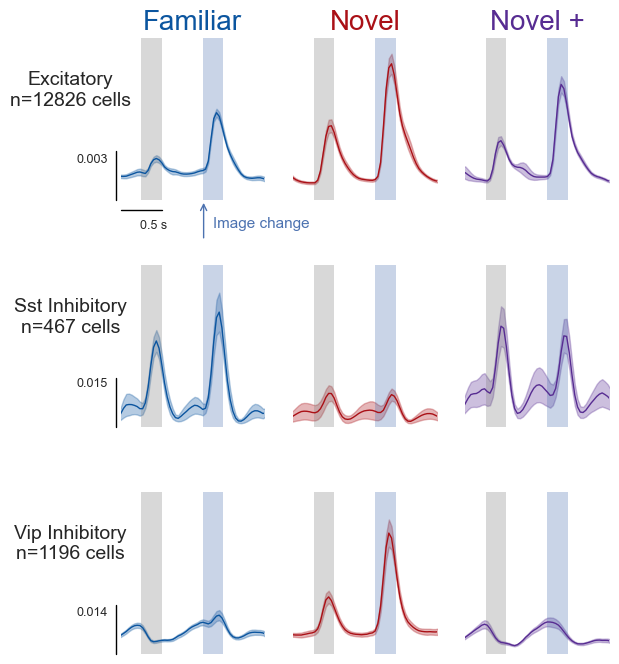

In [ ]:
df = change_mdf.copy()
xlim_seconds = [-1., 0.75]

ppf.plot_population_averages_for_cell_types_across_experience(
    df, xlim_seconds=xlim_seconds, xlabel='Time from image change (s)',
    ylabel='Calcium events', data_type=data_type, event_type='changes',
    interval_sec=1, save_dir=save_dir, folder='population_activity',
    suffix='_changes_stacked', ax=None)

#### Quantification of mean response

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this messag

saving_stats


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


array([<Axes: ylabel='Excitatory'>,
       <Axes: ylabel='Mean non-change image response\n\nSst Inhibitory'>,
       <Axes: ylabel='Vip Inhibitory'>], dtype=object)

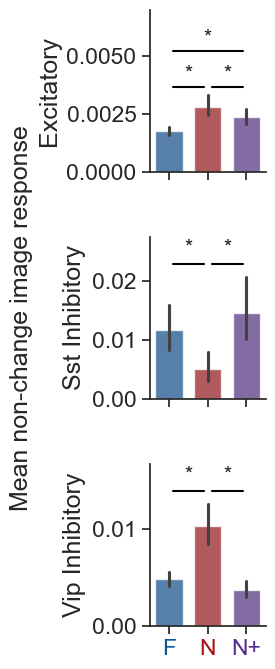

In [ ]:
metric = 'mean_response_all_images'
ylabel = 'Mean non-change image response'

event_type = 'all'

ppf.plot_metric_distribution_by_experience(metrics_table, metric, plot_type='barplot', #show_containers=True,
                                           horiz=False, add_zero_line=False, event_type=event_type, data_type=data_type,
                                           ylabel=ylabel, ylims=None, save_dir=save_dir, ax=None)



/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this messag

saving_stats


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


array([<Axes: ylabel='Excitatory'>,
       <Axes: ylabel='Mean image change response\n\nSst Inhibitory'>,
       <Axes: ylabel='Vip Inhibitory'>], dtype=object)

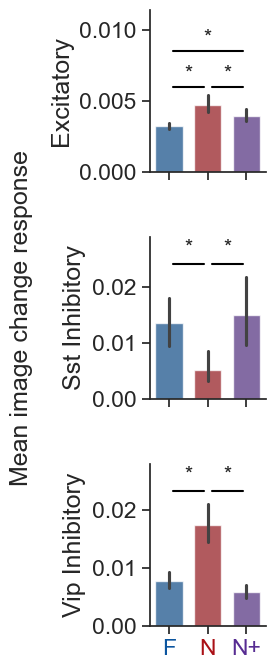

In [ ]:
metric = 'mean_response_changes'
ylabel = 'Mean image change response'

event_type = 'changes'

ppf.plot_metric_distribution_by_experience(metrics_table, metric, plot_type='barplot', 
                                           horiz=False, add_zero_line=False, event_type=event_type, data_type=data_type,
                                           ylabel=ylabel, ylims=None, save_dir=save_dir, ax=None)



/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this messag

saving_stats


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


array([<Axes: ylabel='Excitatory'>,
       <Axes: ylabel='Mean non-change image response - pref image\n\nSst Inhibitory'>,
       <Axes: ylabel='Vip Inhibitory'>], dtype=object)

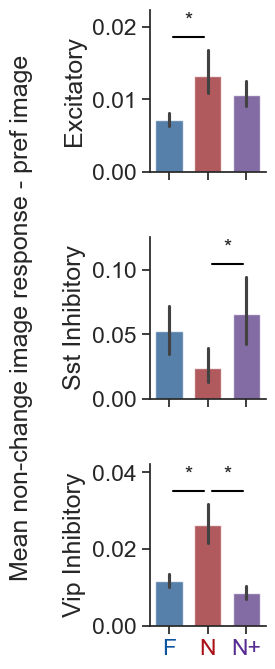

In [ ]:
metric = 'mean_response_pref_image'
ylabel = 'Mean non-change image response - pref image'
event_type = 'pref_image'

ppf.plot_metric_distribution_by_experience(metrics_table, metric, plot_type='barplot', #show_containers=True,
                                           horiz=False, add_zero_line=False, event_type=event_type, data_type=data_type,
                                           ylabel=ylabel, ylims=None, save_dir=save_dir, ax=None)



#### Percent responsive cells

Excitatory includes 62 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1309: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


Sst Inhibitory includes 30 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1309: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


Vip Inhibitory includes 42 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1309: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats


array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}, ylabel='% Non-change image responsive cells'>,
       <Axes: title={'center': 'Vip Inhibitory'}>], dtype=object)

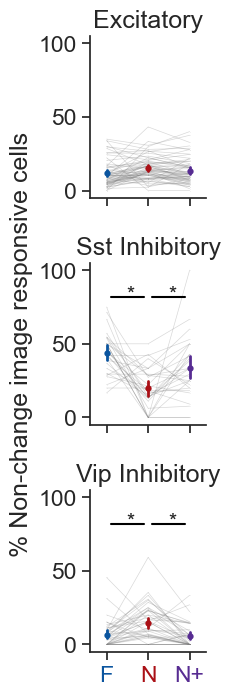

In [ ]:
# Quantify fraction of cells responsive to their preferred stimulus
df = each_image_mdf[(each_image_mdf.is_change==False)& (each_image_mdf.pref_stim==True)]

ppf.plot_percent_responsive_cells(df, responsiveness_threshold=0.2, ylim=(-5, 105), ylabel='% Non-change image responsive cells',
                                    save_dir=save_dir, folder =folder, suffix='_images_pref_stim', horizontal=False, ax=None, event_type='images')


Excitatory includes 62 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1309: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


Sst Inhibitory includes 30 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1309: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


Vip Inhibitory includes 42 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1309: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats


array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}, ylabel='% Image change responsive cells'>,
       <Axes: title={'center': 'Vip Inhibitory'}>], dtype=object)

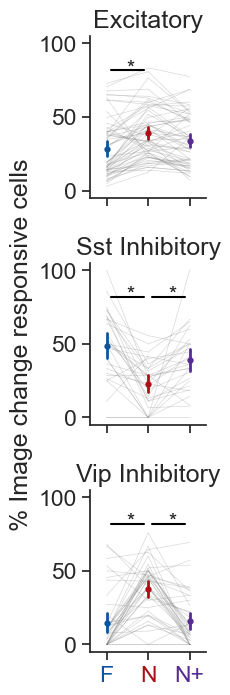

In [ ]:
# Quantify fraction of cells responsive to their preferred stimulus
df = each_image_mdf[(each_image_mdf.is_change==True)& (each_image_mdf.pref_stim==True)]

ppf.plot_percent_responsive_cells(df, responsiveness_threshold=0.2, ylim=(-5, 105), ylabel='% Image change responsive cells',
                                    save_dir=save_dir, folder =folder, suffix='_changes_pref_stim', horizontal=False, ax=None, event_type='changes')


#### Change modulation

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:2674: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax[i] = sns.pointplot(data=ct_data, y=y, x=x, order=experience_levels,
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaini

saving_stats


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}, ylabel='Change modulation'>,
       <Axes: title={'center': 'Vip Inhibitory'}>], dtype=object)

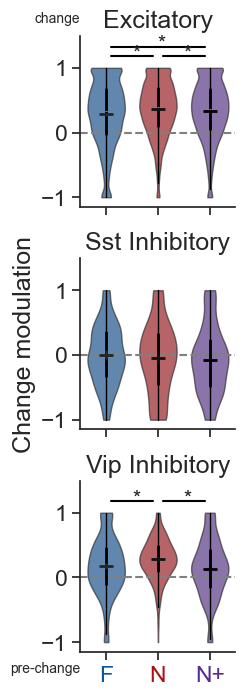

In [ ]:
metric = 'change_modulation_index'
xlabel = 'Change modulation'
event_type = 'changes'
annot = ('pre-change', 'change')
xlims = (-1.15, 1.15)

ppf.plot_modulation_index_distribution(metrics_table, metric, label=xlabel, 
                                       lims=xlims, horiz=False, annot=annot, metric_on_y=True,
                                        abbreviate_exp=True, suptitle=None, fill=True, 
                                        save_dir=save_dir, event_type='changes')


In [ ]:
missing_ids = metrics_table.loc[
    ~metrics_table['ophys_experiment_id'].isin(change_mdf['ophys_experiment_id']),
    'ophys_experiment_id'].unique()

tmp = metrics_table[metrics_table.ophys_experiment_id.isin(missing_ids)==False]

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:2674: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax[i] = sns.pointplot(data=ct_data, y=y, x=x, order=experience_levels,
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaini

saving_stats


array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}, ylabel='Change modulation'>,
       <Axes: title={'center': 'Vip Inhibitory'}>], dtype=object)

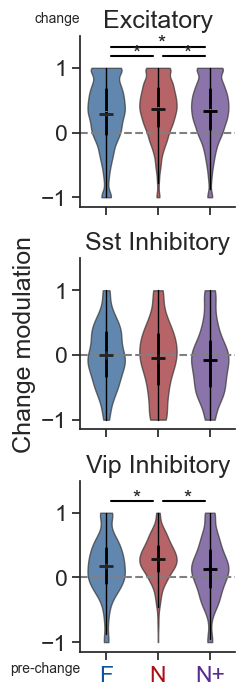

In [ ]:
metric = 'change_modulation_index'
xlabel = 'Change modulation'
event_type = 'changes'
annot = ('pre-change', 'change')
xlims = (-1.15, 1.15)

ppf.plot_modulation_index_distribution(tmp, metric, label=xlabel, 
                                       lims=xlims, horiz=False, annot=annot, metric_on_y=True,
                                        abbreviate_exp=True, suptitle=None, fill=True, 
                                        save_dir=save_dir, event_type='changes')


In [ ]:
print('image_mdf.mouse_id dtype:', image_mdf.mouse_id.dtype)
print('platform_cells_table.mouse_id dtype:', platform_cells_table.mouse_id.dtype)

image_mdf.mouse_id dtype: object
platform_cells_table.mouse_id dtype: int64


#### Experience modulation

Quantification of how neural responses change across experience levels. Includes
experience modulation index (computed as the difference in mean response between
two experience levels divided by the sum) for each cell, shown as distributions
per cell type. Also shows mean image change response magnitude across cohorts,
depths, and cortical areas, and the change modulation index (response to image
changes minus response to non-change images, over the sum) split by area and
depth. Corresponds to PPT Figure S7 panels I-N.

In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}>,
       <Axes: title={'center': 'Vip Inhibitory'}, xlabel='Experience modulation'>],
      dtype=object)

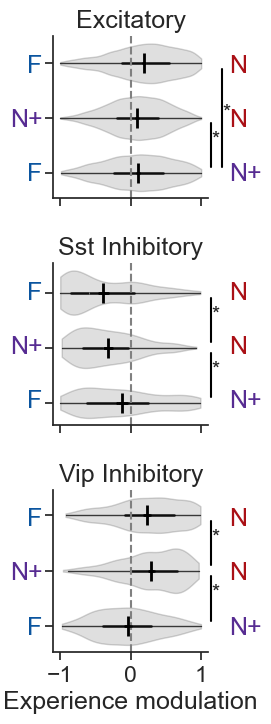

In [ ]:
metric = 'mean_response'
event_type = 'images'
xlabel = 'Experience modulation'

ppf.plot_experience_modulation_index_annotated_by_cell_type(image_mdf, event_type, metric, platform_cells_table,
                                                            xlims=(-1.1, 1.1), xlabel=xlabel,
                                                            all_comparisons=True, horiz=False,
                                                            suptitle=None, suffix='', save_dir=None, ax=None)

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3264: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_yticklabels([cell_type[:3] for cell_type in cell_types])
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3264: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_yticklabels([cell_type[:3] for cell_type in cell_types])
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3264: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_yticklabels([cell_type[:3] for cell_type in cell_types])


saving_stats


array([<Axes: title={'center': 'Novel vs. Familiar'}>,
       <Axes: title={'center': 'Novel vs. Novel +'}>,
       <Axes: title={'center': 'Novel + vs. Familiar'}, xlabel='Experience modulation'>],
      dtype=object)

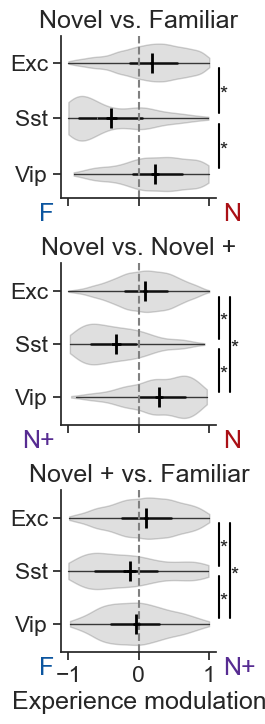

In [ ]:
metric = 'mean_response'
event_type = 'images'
xlabel = 'Experience modulation'

ppf.plot_experience_modulation_index_annotated(
    image_mdf, event_type, metric, platform_cells_table,
    horiz=False, xlims=(-1.1, 1.1), xlabel='Experience modulation',
    suffix='_images_modulation', save_dir=save_dir,)

##### Experience vs change modulation 

### Population activity for image omissions

#### Population mean response

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

removing 1 problematic experiments


array([<Axes: title={'center': 'Familiar'}, ylabel='Excitatory\nn=12826 cells'>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Sst Inhibitory\nn=467 cells'>, <Axes: >, <Axes: >,
       <Axes: ylabel='Vip Inhibitory\nn=1197 cells'>, <Axes: >, <Axes: >],
      dtype=object)

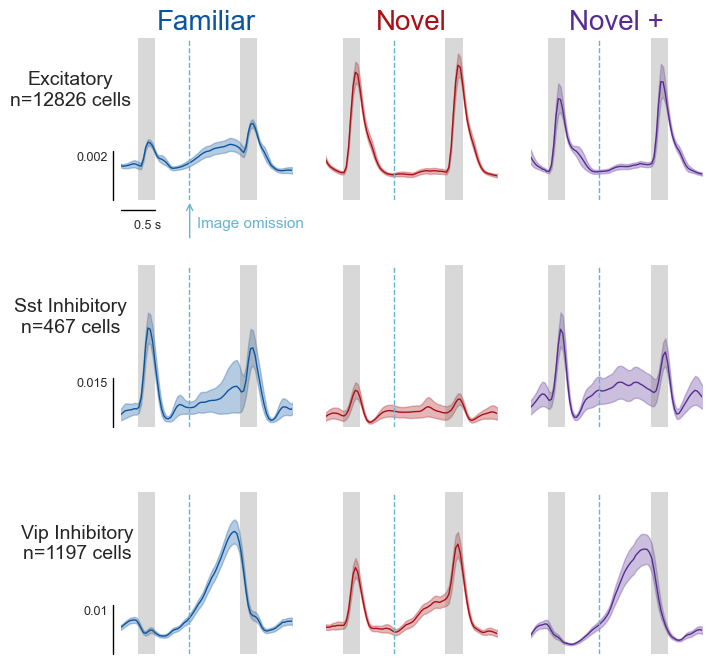

In [ ]:
df = omission_mdf.copy()
xlim_seconds = [-1., 1.5]

ppf.plot_population_averages_for_cell_types_across_experience(
    df, xlim_seconds=xlim_seconds, xlabel='Time from image omission (s)',
    ylabel='Calcium events', data_type=data_type, event_type='omissions',
    interval_sec=1, save_dir=save_dir, folder='population_activity',
    suffix='', ax=None)

### Quantification of mean response

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/statsmodels/base/model.py:1914: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this messag

saving_stats


array([<Axes: ylabel='Excitatory'>,
       <Axes: ylabel='Mean image omission response\n\nSst Inhibitory'>,
       <Axes: ylabel='Vip Inhibitory'>], dtype=object)

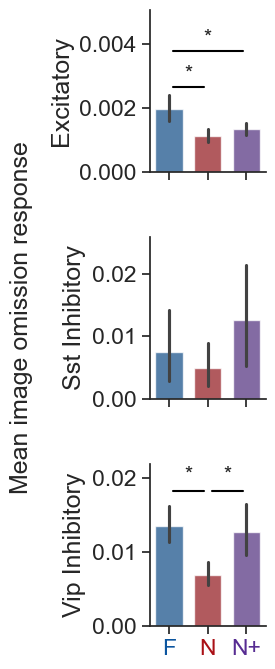

In [ ]:
metric = 'mean_response_omissions'
ylabel = 'Mean image omission response'
event_type = 'omissions'

ppf.plot_metric_distribution_by_experience(
    metrics_table, metric, plot_type='barplot', horiz=False,
    suptitle='', add_zero_line=False, event_type=event_type, data_type=data_type,
    ylabel=ylabel, ylims=None, save_dir=save_dir, ax=None)

#### Percent responsive cells 

Excitatory includes 62 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1309: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


Sst Inhibitory includes 30 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1309: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


Vip Inhibitory includes 42 containers


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:1309: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(utils.get_abbreviated_experience_levels(), rotation=0)


saving_stats


array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}, ylabel='% Image omission responsive cells'>,
       <Axes: title={'center': 'Vip Inhibitory'}>], dtype=object)

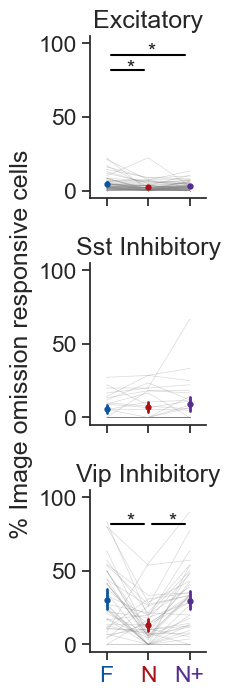

In [ ]:
# Quantify fraction of cells responsive to their preferred stimulus
df = omission_mdf.copy()

ppf.plot_percent_responsive_cells(df, responsiveness_threshold=0.1, ylim=(-5, 105), 
                                    ylabel='% Image omission responsive cells',
                                    save_dir=save_dir, folder =folder, suffix='_omissions_pref_stim', 
                                    horizontal=False, ax=None, event_type='omissions')


### Single cell diversity

Example container and cells for matched cell plotting

#### Matched cell response heatmaps

##### Image changes

array([<Axes: title={'center': 'Familiar'}, ylabel='Excitatory\nmatched cells'>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Sst Inhibitory\nmatched cells'>, <Axes: >, <Axes: >,
       <Axes: ylabel='Vip Inhibitory\nmatched cells'>,
       <Axes: xlabel='Time from image onset (s)'>, <Axes: >], dtype=object)

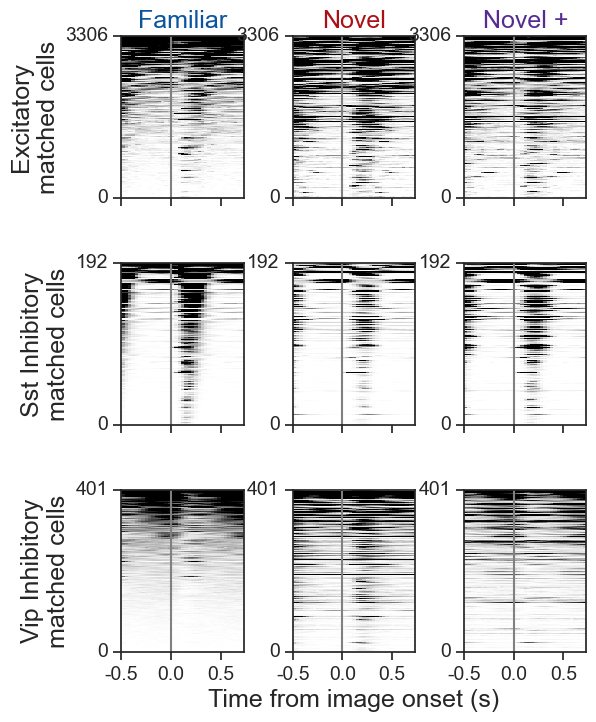

In [ ]:
df = image_mdf.copy()

xlim_seconds = [-0.5, 0.75]

event_type = 'images'

timestamps = df.trace_timestamps.values[0]
row_condition = 'cell_type'
col_condition = 'experience_level'

ppf.plot_response_heatmaps_for_conditions(df, timestamps, data_type, event_type, row_condition, col_condition, 
                                          col_to_sort_by='mean_baseline', suptitle='', xlabel='Time from image onset (s)',
                                          match_cells=True, matched_cells_table=matched_cells_table,
                                          exp_to_match='Familiar', xlim_seconds=xlim_seconds, cbar=False,
                                          save_dir=save_dir, folder=folder, suffix='', ax=None)



array([<Axes: title={'center': 'Familiar'}, ylabel='Excitatory\nmatched cells'>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Sst Inhibitory\nmatched cells'>, <Axes: >, <Axes: >,
       <Axes: ylabel='Vip Inhibitory\nmatched cells'>,
       <Axes: xlabel='Time from image change (s)'>, <Axes: >],
      dtype=object)

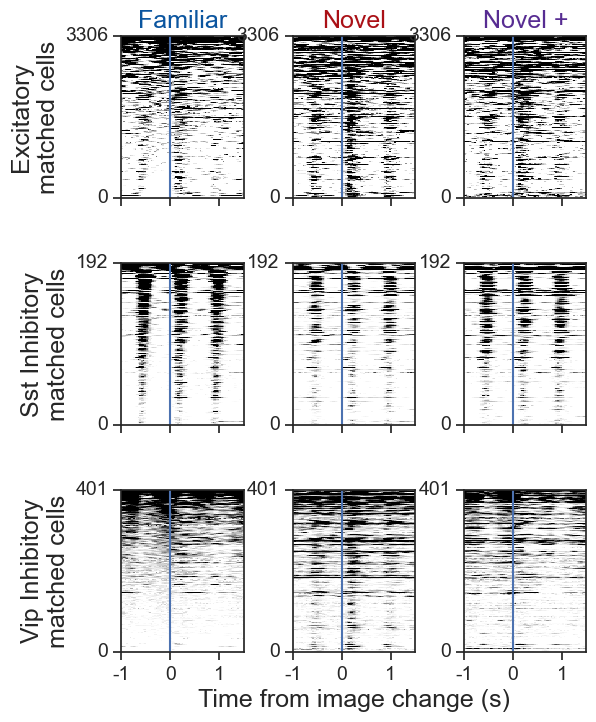

In [ ]:
# Cell-matched response heatmaps for images
timestamps = change_mdf.trace_timestamps.values[0]
row_condition = 'cell_type'
col_condition = 'experience_level'
cols_to_sort_by = ['mean_response']

# Cell-matched population averages for changes
matched_changes = utilities.limit_to_cell_specimen_ids_matched_in_all_experience_levels(change_mdf)
xlim_seconds = [-1., 1.5]

# Cell-matched response heatmaps for changes
ppf.plot_response_heatmaps_for_conditions(
    matched_changes, timestamps, data_type, 'changes', row_condition, col_condition,
    col_to_sort_by='mean_baseline', suptitle='Matched cells - Changes',
    xlabel='Time from image change (s)', exp_to_match='Familiar', matched_cells_table=matched_cells_table,
    microscope=None, xlim_seconds=[-1, 1.5], match_cells=True, cbar=False,
    save_dir=save_dir, folder=folder, suffix='_matched_changes', ax=None)

##### Image omissions

array([<Axes: title={'center': 'Familiar'}, ylabel='Excitatory\ncells'>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Sst Inhibitory\ncells'>, <Axes: >, <Axes: >,
       <Axes: ylabel='Vip Inhibitory\ncells'>,
       <Axes: xlabel='Time from image omission (s)'>, <Axes: >],
      dtype=object)

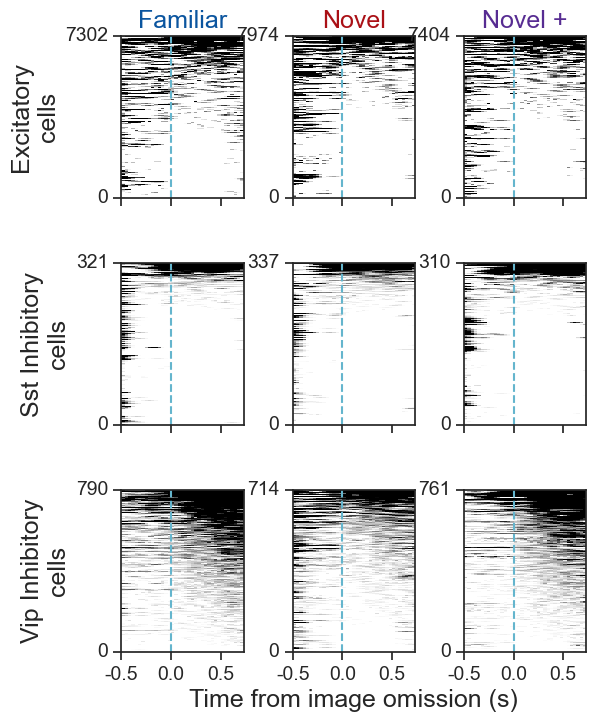

In [ ]:
df = omission_mdf.copy()

xlim_seconds = [-0.5, 0.75]

event_type = 'omissions'

timestamps = df.trace_timestamps.values[0]
row_condition = 'cell_type'
col_condition = 'experience_level'

ppf.plot_response_heatmaps_for_conditions(df, timestamps, data_type, event_type, row_condition, col_condition, 
                                          col_to_sort_by='mean_response', suptitle='', xlabel='Time from image omission (s)',
                                          microscope=None, vmax=None, xlim_seconds=xlim_seconds, match_cells=False, cbar=False,
                                          save_dir=None, folder=folder, suffix='_heatmap_omissions', ax=None)

array([<Axes: title={'center': 'Familiar'}, ylabel='Excitatory\nmatched cells'>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Sst Inhibitory\nmatched cells'>, <Axes: >, <Axes: >,
       <Axes: ylabel='Vip Inhibitory\nmatched cells'>,
       <Axes: xlabel='Time from omission (s)'>, <Axes: >], dtype=object)

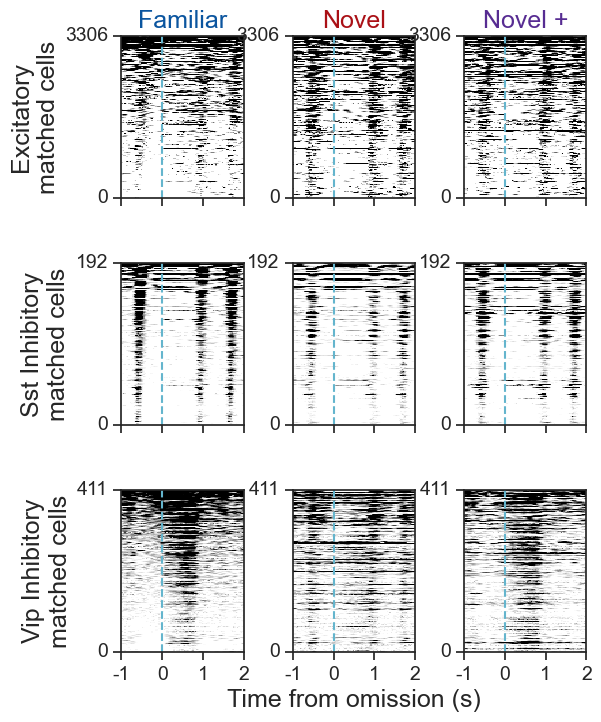

In [ ]:
# Population averages for omissions - heatmaps
timestamps = omission_mdf.trace_timestamps.values[0]
row_condition = 'cell_type'
col_condition = 'experience_level'

# Cell-matched omission heatmaps
matched_omissions = utilities.limit_to_cell_specimen_ids_matched_in_all_experience_levels(omission_mdf)

ppf.plot_response_heatmaps_for_conditions(
    matched_omissions, timestamps, data_type, 'omissions', row_condition, col_condition,
    col_to_sort_by='mean_baseline', suptitle='Matched cells - Omissions',
    xlabel='Time from omission (s)', exp_to_match='Familiar', matched_cells_table=matched_cells_table,
    microscope=None, xlim_seconds=[-1, 2], match_cells=True, cbar=False,
    save_dir=save_dir, folder=folder, suffix='_matched_omissions', ax=None)

#### Matched cell example responses across sessions 

In [ ]:
Vip_containers = [1018027599, 1018027859, 1046576787, 1018027862, 1018028367]

Sst_containers = [1018028339, 1018028135, 1018028202, 1018028153, 1074913336]

Exc_containers = [1018027663, 1018027790, 1018028046, 1074922997, 1079028117, 1018027775,]


##### Image changes

In [ ]:
%load_ext autoreload
%autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


###### Excitatory

In [ ]:
# Exc_change_cells = [1086579153, 1086559786, 1086523675,  1086514966, 1086514622, 1120104688,  #1086514606, ]
#                      1086558573, 1086527750, 1086517398, 1086577182, 1120108338, 1086510825, ]#1086558285, 1086519596, 1086529704, ]

# event_type = 'images'
# cell_type = 'Excitatory'

# df = each_image_mdf[(each_image_mdf.pref_stim==True) & (each_image_mdf.is_change==False)].copy()

# pse.plot_reliable_example_cells(df, Exc_change_cells[:4], cell_type, event_type=event_type, 
#                                 xlim_seconds=[-0.25, 0.75],
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_images_selected')


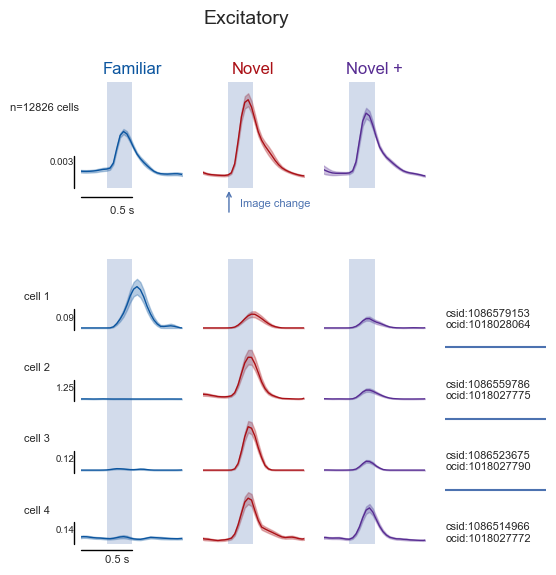

In [ ]:
Exc_change_cells = [1086579153, 1086559786, 1086523675,  1086514966, 1086514622, 1120104688,  #1086514606, ]
                     1086558573, 1086527750, 1086517398, 1086577182, 1120108338, 1086510825, ]#1086558285, 1086519596, 1086529704, ]

event_type = 'changes'

cell_type = 'Excitatory'
pse.plot_reliable_example_cells(change_mdf, Exc_change_cells[:4], cell_type, event_type=event_type, 
                                xlim_seconds=[-0.25, 0.75],
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


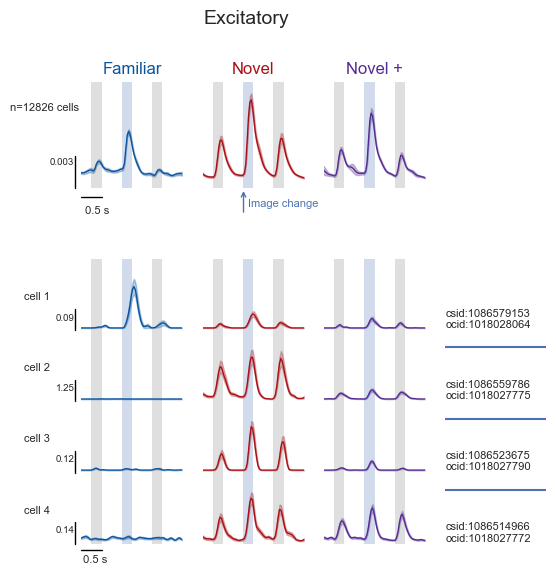

In [ ]:
Exc_change_cells = [1086579153, 1086559786, 1086523675,  1086514966, 1086514622, 1120104688,  1086514606, 
                     1086558573, 1086527750, 1086517398, 1086577182, 1120108338, 1086510825, 1086558285, 1086519596, 1086529704, ]

event_type = 'changes'

cell_type = 'Excitatory'
pse.plot_reliable_example_cells(change_mdf, Exc_change_cells[:4], cell_type, event_type=event_type, 
                                xlim_seconds=[-1, 1.5],
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


In [ ]:
%load_ext autoreload
%autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


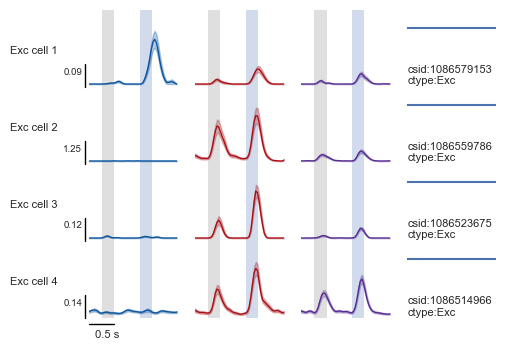

In [ ]:
Exc_change_cells = [1086579153, 1086559786, 1086523675,  1086514966, 1086514622, 1120104688,  #1086514606, ]
                     1086558573, 1086527750, 1086517398, 1086577182, 1120108338, 1086510825, ]#1086558285, 1086519596, 1086529704, ]

event_type = 'changes'

pse.plot_selected_cell_examples(change_mdf, Exc_change_cells[:4], event_type=event_type,
                                xlim_seconds=[-1, 0.75], linewidth=1, save_dir=save_dir, 
                                folder='selected_example_cells', suffix='_Exc_changes')
    


In [ ]:
Exc_change_cells = matched_cells_table[(matched_cells_table.cell_type=='Excitatory') & 
                                        (matched_cells_table.project_code=='VisualBehavior') &
                                        (matched_cells_table.binned_depth==175)].cell_specimen_id.unique()
Exc_change_cells = np.random.choice(Exc_change_cells, 10)

In [8]:
# for cell_specimen_id in Exc_change_cells:
#     pse.plot_matched_roi_mask_zoom(cell_specimen_id, platform_cells_table, platform_experiments, save_dir=save_dir)


###### Sst Inhibitory

{974994093: [1086537043, 1086526518, 1086520057],
 974994095: [1086519261],
 974433388: [1086526678, 1086519261],
 974433395: [1086535501, 1086515669],
 974433397: [1086529269, 1086525465, 1086516056],
 974994101: [1086518655],
 974994105: [1086524231],
 905955204: [1086528784, 1086549714, 1086549924, 1086535478, 1086563886],
 905955213: [1086525861, 1086532875, 1086532286],
 905955219: [1086509036],
 906910612: [1086545900, 1086570627, 1086565536, 1086596382, 1086568462],
 906910627: [1086525115, 1086525369, 1086525010],
 1076808560: [1120091915, 1120091440, 1120091606, 1120091844, 1120091558],
 1076808556: [1120094297, 1120094089, 1120094237, 1120094842],
 1076808568: [1120096184],
 1076808562: [1120094103, 1120093912]}

In [ ]:
# Sst_change_cells =  [1086579643, 1120094089, 1086575280, 1086551540, 1086581760, 1086572621, ]
#                     # 1086559885, 1086619787, 1086553602, 1120094297]
# #1086575742, ]
# cell_type = 'Sst Inhibitory'
# event_type = 'images'
# df = each_image_mdf[(each_image_mdf.pref_stim==True) & (each_image_mdf.is_change==False)].copy()

# pse.plot_reliable_example_cells(df, Sst_change_cells[:4], cell_type, event_type=event_type, 
#                                 xlim_seconds=[-0.25, 0.75],
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


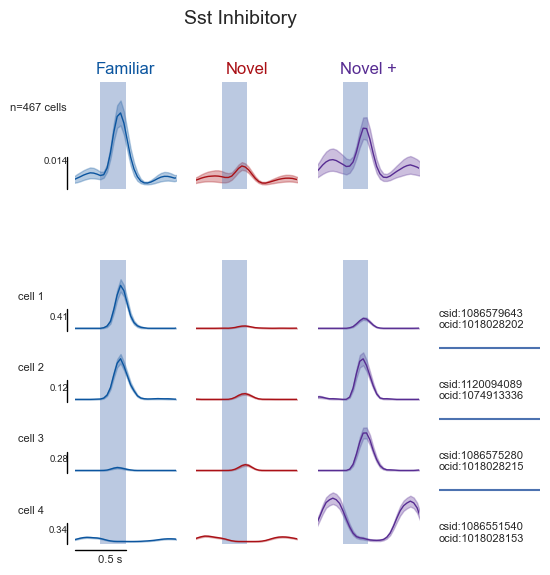

In [ ]:
Sst_change_cells =  [1086579643, 1120094089, 1086575280, 1086551540, 1086581760, 1086572621, ]
                    # 1086559885, 1086619787, 1086553602, 1120094297]
#1086575742, ]
cell_type = 'Sst Inhibitory'
event_type = 'changes'

pse.plot_reliable_example_cells(change_mdf, Sst_change_cells[:4], cell_type, event_type=event_type, 
                                xlim_seconds=[-0.25, 0.75],
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


In [ ]:
# Sst_change_cells =  [1086579643, 1120094089, 1086575280, 1086551540, 1086581760, 1086572621, ]
#                     # 1086559885, 1086619787, 1086553602, 1120094297]
# #1086575742, ]
# cell_type = 'Sst Inhibitory'
# event_type = 'changes'

# pse.plot_reliable_example_cells(change_mdf, Sst_change_cells[:4], cell_type, event_type=event_type, 
#                                 xlim_seconds=[-1, 0.75],
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')

In [ ]:
# Sst_change_cells =  [1086579643, 1120094089, 1086575280, 1086551540, 1086581760, 1086572621, ]
#                     # 1086559885, 1086619787, 1086553602, 1120094297]
# #1086575742, ]
# cell_type = 'Sst Inhibitory'
# event_type = 'changes'

# pse.plot_reliable_example_cells(change_mdf, Sst_change_cells[:4], cell_type, event_type=event_type, 
#                                 xlim_seconds=[-1, 0.75],
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


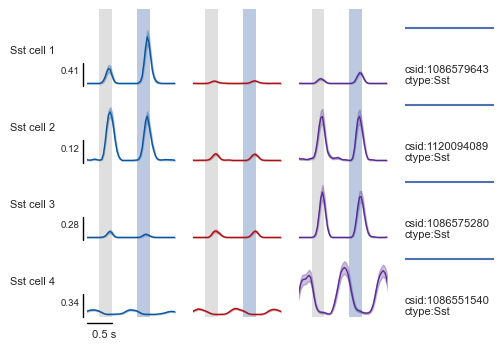

In [ ]:
Sst_change_cells =  [1086579643, 1120094089, 1086575280, 1086551540, 1086581760, 1086572621, ]

cell_type = 'Sst Inhibitory'
event_type = 'changes'

pse.plot_selected_cell_examples(change_mdf, Sst_change_cells[:4], event_type=event_type,
                                xlim_seconds=[-1, 0.75], linewidth=1, save_dir=save_dir, 
                                folder='selected_example_cells', suffix='_Sst_changes')
    

In [ ]:
    
# for cell_specimen_id in Sst_change_cells[:4]:
#     pse.plot_matched_roi_mask_zoom(cell_specimen_id, platform_cells_table, platform_experiments, save_dir=save_dir)


###### Vip Inhibitory

In [ ]:
# Vip_change_cells = [1086673402, 1086501825, 1086627590, 1086514444, 1086627527, 1086514260, ] 

# itory'
# event_type = 'images'
# df = each_image_mdf[(each_image_mdf.pref_stim==True) & (each_image_mdf.is_change==False)].copy()

# pse.plot_reliable_example_cells(df, Vip_change_cells[:4], cell_type, event_type=event_type, 
#                                 xlim_seconds=[-0.25, 0.75],
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


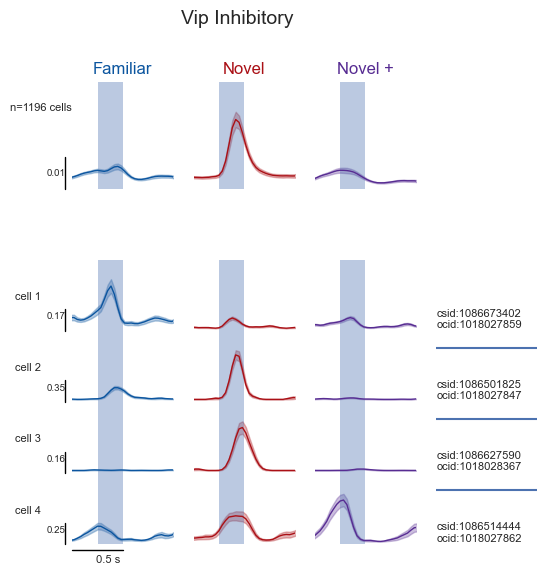

In [ ]:

Vip_change_cells = [1086673402, 1086501825, 1086627590, 1086514444, 1086627527, 1086514260, ] 
# 1086627395, 1086673073, 1086519532, 1086516885, 1086615418, ]
event_type='changes'
cell_type = 'Vip Inhibitory'
pse.plot_reliable_example_cells(change_mdf, Vip_change_cells[:4], cell_type, event_type=event_type, 
                                xlim_seconds=[-0.25, 0.75],
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


In [ ]:
# event_type='changes'
# cell_type = 'Vip Inhibitory'
# pse.plot_reliable_example_cells(change_mdf, Vip_change_cells[:4], cell_type, event_type=event_type, 
#                                 xlim_seconds=[-1, 1.5],
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


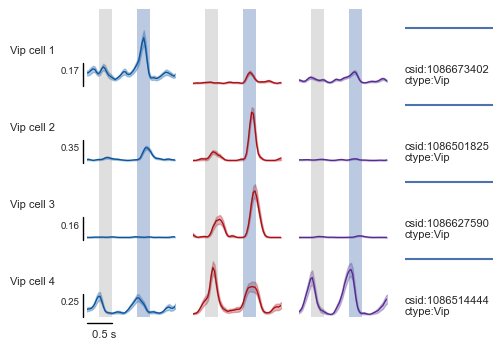

In [ ]:
Vip_change_cells = [1086673402, 1086501825, 1086627590, 1086514444, 1086627527, 1086514260, ] 

event_type = 'changes'

pse.plot_selected_cell_examples(change_mdf, Vip_change_cells[:4], event_type=event_type,
                                xlim_seconds=[-1, 0.75], linewidth=1, save_dir=save_dir, 
                                folder='selected_example_cells', suffix='_Vip_changes')
    


In [ ]:
# for cell_specimen_id in Vip_change_cells[4:]:
#     pse.plot_matched_roi_mask_zoom(cell_specimen_id, platform_cells_table, platform_experiments, save_dir=save_dir)


##### Image omissions

In [ ]:
# Exc_omission_cells = [ 1086529704, 1120092455, 1120102262, 1086571711,  1086514606, 
#                       1086530117, 1120090879,  1086526518,]
# event_type = 'omissions'

# cell_type = 'Excitatory'
# pse.plot_reliable_example_cells(omission_mdf, Exc_omission_cells[:4], cell_type, event_type=event_type, 
#                                 xlim_seconds=[-1, 1.5],
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')

In [ ]:
# Exc_omission_cells = [ 1086529704, 1120092455, 1120102262, 1086571711,  1086514606, 
#                       1086530117, 1120090879,  1086526518,]
# event_type = 'omissions'

# pse.plot_selected_cell_examples(omission_mdf, Exc_omission_cells[:4], event_type=event_type,
#                                 xlim_seconds=[-1, 1.5], linewidth=1, save_dir=save_dir, 
#                                 folder='selected_example_cells', suffix='_Exc_omissions')
    


In [ ]:
# cell_types = utils.get_cell_types()
# cell_type = 'Excitatory'
# # for cell_type in cell_types: 
# event_type = 'omissions'
# # get reliable cells for this cell type
# reliable_cells = omission_mdf[(omission_mdf.fraction_significant_p_value_gray_screen>0.15) & 
#             (omission_mdf.mean_response > 0.1) &
#             (omission_mdf.cell_type==cell_type)]
# reliable_cells = reliable_cells.sort_values(by=['ophys_container_id', 'cell_specimen_id'])
# cells_to_plot = reliable_cells.cell_specimen_id.unique()
# print(len(cells_to_plot))

# pse.plot_reliable_example_cells(omission_mdf, cells_to_plot, cell_type, event_type=event_type, 
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_top_cells')

In [ ]:
# Sst_omission_cells = [1120094842,  1086557434, 1086551540, 1086575742, 1086569242, 
#                      1086620900,  1086556653, 1086559850, 1086619649,]

# event_type = 'omissions'

# cell_type = 'Sst Inhibitory'
# pse.plot_reliable_example_cells(omission_mdf, Sst_omission_cells[:4], cell_type, event_type=event_type, 
#                                 xlim_seconds=[-1, 1.5],
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')

In [ ]:
# Sst_omission_cells = [1120094842,  1086557434, 1086551540, 1086575742, 1086569242, 
#                      1086620900,  1086556653, 1086559850, 1086619649,]

# event_type = 'omissions'

# pse.plot_selected_cell_examples(omission_mdf, Sst_omission_cells[:4], event_type=event_type,
#                                 xlim_seconds=[-1, 1.5], linewidth=1, save_dir=save_dir, 
#                                 folder='selected_example_cells', suffix='_Sst_omissions')
    


In [ ]:
# cell_types = utils.get_cell_types()
# cell_type = 'Sst Inhibitory'
# # for cell_type in cell_types: 
# event_type = 'omissions'
# # get reliable cells for this cell type
# reliable_cells = omission_mdf[(omission_mdf.fraction_significant_p_value_gray_screen>0.15) & 
#             (omission_mdf.mean_response > 0.1) &
#             (omission_mdf.cell_type==cell_type)]
# reliable_cells = reliable_cells.sort_values(by=['ophys_container_id', 'cell_specimen_id'])
# cells_to_plot = reliable_cells.cell_specimen_id.unique()
# print(len(cells_to_plot))

# pse.plot_reliable_example_cells(omission_mdf, cells_to_plot, cell_type, event_type=event_type, 
#                                 save_dir=save_dir, folder='reliable_example_cells', suffix='_top_cells')

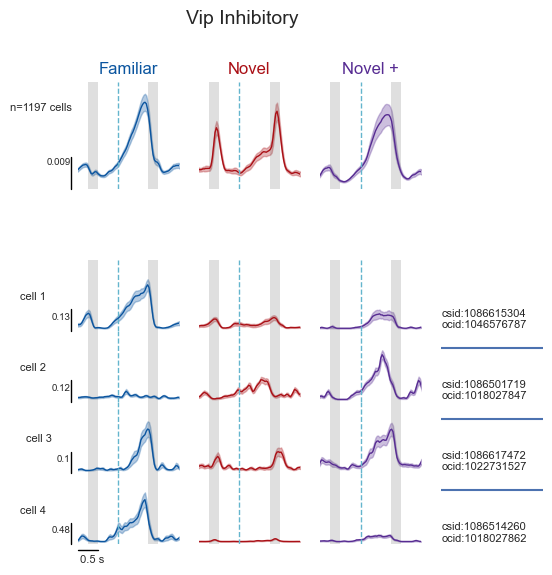

In [ ]:
Vip_omission_cells = [1086615304, 1086501719, 1086617472, 1086514260, 1086616294, 1086514444, 
                      1086614936 ,1086614349, 1086510096, 1086673225,  1086516885, 1086627910,  ]
                      
event_type = 'omissions'

cell_type = 'Vip Inhibitory'
pse.plot_reliable_example_cells(omission_mdf, Vip_omission_cells[:4], cell_type, event_type=event_type, 
                                xlim_seconds=[-1, 1.5],
                                save_dir=save_dir, folder='reliable_example_cells', suffix='_selected')


In [ ]:
# Vip_omission_cells = [1086615304, 1086501719, 1086617472, 1086514260, 1086616294, 1086514444, 
#                       1086614936 ,1086614349, 1086510096, 1086673225,  1086516885, 1086627910,  ]
                      
# event_type = 'omissions'


# pse.plot_selected_cell_examples(omission_mdf, Vip_omission_cells[:4], event_type=event_type,
#                                 xlim_seconds=[-1, 1.5], linewidth=1, save_dir=save_dir, 
#                                 folder='selected_example_cells', suffix='_Vip_omissions')
    


#### Across cre examples for omissions

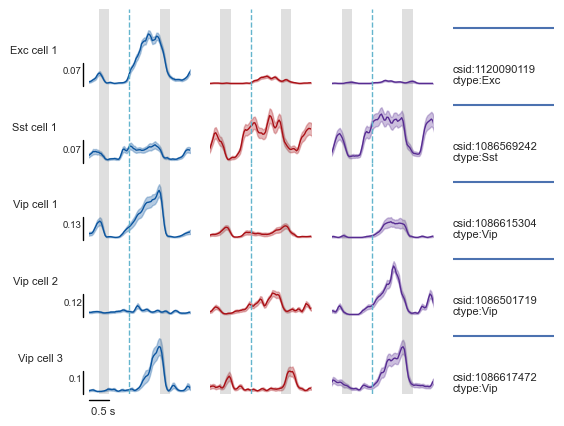

In [ ]:
cells_to_plot = [1120090119, # Exc
                 1086569242, # Sst
                 1086615304, # Vip
                 1086501719, # Vip
                 1086617472, # Vip
                ]
event_type = 'omissions'

pse.plot_selected_cell_examples(omission_mdf, cells_to_plot, event_type=event_type,
                                xlim_seconds=[-1, 1.5], linewidth=1, save_dir=save_dir, 
                                folder='selected_example_cells', suffix='_omissions')
    

#### Plot ROI zoom for example cells 

In [ ]:
%load_ext autoreload
%autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# cells_to_plot = [1120090119, # Exc
#                  1086569242, # Sst
#                  1086615304, # Vip
#                  1086501719, # Vip
#                  1086617472, # Vip
#                 ]

# cell_specimen_id = cells_to_plot[0]

# for cell_specimen_id in cells_to_plot:
#     pse.plot_matched_roi_mask_zoom(cell_specimen_id, platform_cells_table, platform_experiments, save_dir=save_dir)
    

#### ROIs and traces across sessions

In [ ]:
ophys_container_id = 835006071 
ophys_container_id = 829561794

array([<Axes: title={'center': '833629926'}>,
       <Axes: title={'center': '834279496'}>,
       <Axes: title={'center': '835006071'}>], dtype=object)

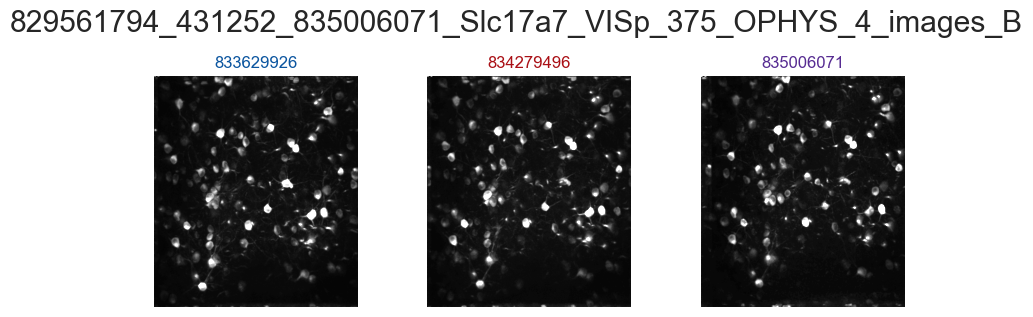

In [ ]:
cell_type = 'Excitatory'

# Get high SNR matched cells for container
matched_cells_snr, dff_metrics = pse.get_high_snr_matched_cells_for_container(ophys_container_id, dataset_dict,
                                                                               matched_cells_table, platform_experiments, 
                                                                               )

# Plot matched max projections for container
# Note: function signature is (ophys_container_id, platform_experiments, dataset_dict, save_dir, ax)
# matched_cells_table is NOT a parameter
pse.plot_matched_max_projections_for_container(ophys_container_id, platform_experiments,
                                              dataset_dict,
                                              save_dir=save_dir, ax=None)



In [ ]:
n_reliable_cells_threshold = 5

reliable_cells = change_mdf[(change_mdf.fraction_significant_p_value_gray_screen>0.15) & 
            (change_mdf.mean_response > 0.02) &
            (change_mdf.cell_type==cell_type) & 
            (change_mdf.ophys_experiment_id.isin(platform_experiments.index.unique()))]

# reliable_cells = pd.concat([reliable_cells_changes, reliable_cells_omissions])
matched_reliable_cells = reliable_cells[reliable_cells.cell_specimen_id.isin(matched_cells_table.cell_specimen_id.unique())]


In [ ]:
start_times = np.asarray([512])
duration_seconds = 18

matched_cells = matched_reliable_cells[matched_reliable_cells.ophys_container_id==ophys_container_id]
matched_cells = matched_cells.sort_values(by='fraction_significant_p_value_gray_screen', ascending=False)
matched_cells = matched_cells.drop_duplicates(subset='cell_specimen_id')
matched_cells = matched_cells.cell_specimen_id.values
print(len(matched_cells))

5


0 out of 1
833629926 Familiar 97 matched cells,  161 total cells
834279496 Novel 97 matched cells,  162 total cells
835006071 Novel + 97 matched cells,  146 total cells
using provided cell_specimen_ids in the order they were provided
using provided cell_specimen_ids in the order they were provided


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/loading.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stimulus_presentations[column] = stimulus_presentations[column].astype('bool')
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/loading.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stimulus_presentations[column] = stimulus_presentations[column].astype('bool')
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_be

using provided cell_specimen_ids in the order they were provided
saving


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/loading.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stimulus_presentations[column] = stimulus_presentations[column].astype('bool')


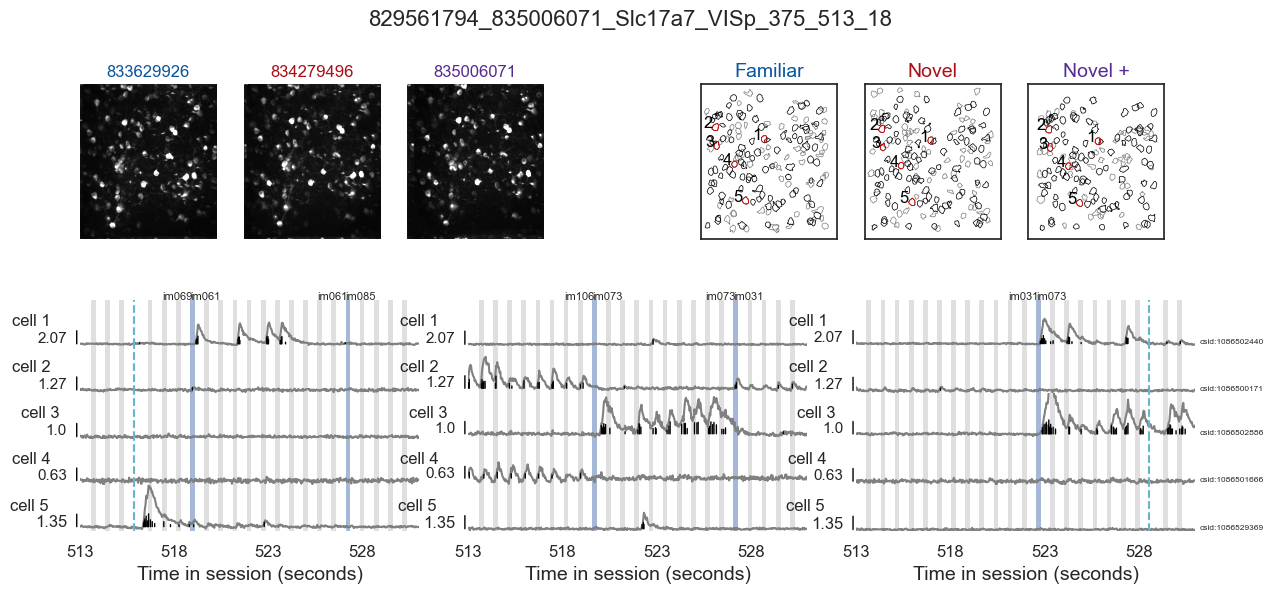

In [ ]:
start_times = np.asarray([513])

csids = [1086502440, 
         1086500171,
         1086502886,
         1086501666, 
         1086529369]

pse.plot_matched_rois_and_traces_for_container(ophys_container_id, dataset_dict,
                                        matched_cells_table, platform_experiments, fontsize=12,
                                        start_times=start_times, duration_seconds=18,
                                        matched_cells=csids, save_dir=save_dir, suffix='')

0 out of 1
using provided cell_specimen_ids in the order they were provided
using provided cell_specimen_ids in the order they were provided


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/loading.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stimulus_presentations[column] = stimulus_presentations[column].astype('bool')
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/loading.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stimulus_presentations[column] = stimulus_presentations[column].astype('bool')
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_be

using provided cell_specimen_ids in the order they were provided
saving


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/loading.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stimulus_presentations[column] = stimulus_presentations[column].astype('bool')
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/loading.py:174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stimulus_presentations[column] = stimulus_presentations[column].astype('bool')
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_be

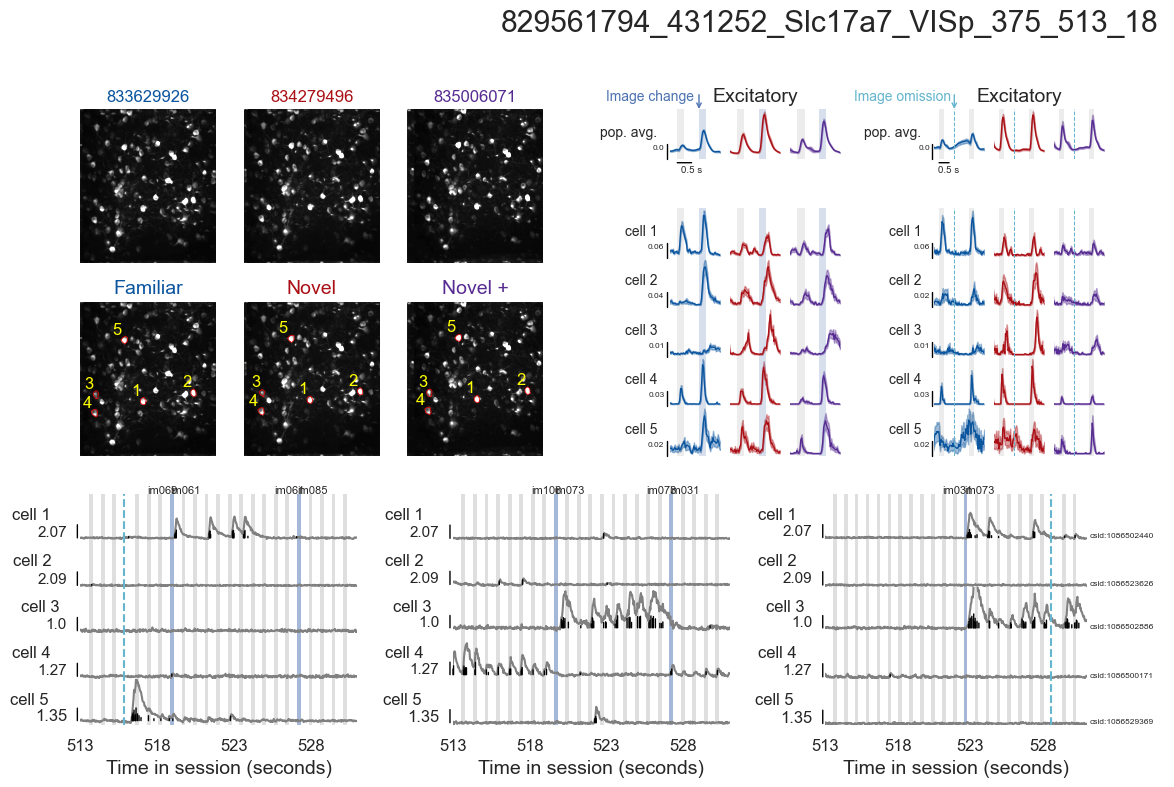

In [ ]:

suffix = '_reliable_cells_selected'

pse.plot_matched_traces_across_sessions(ophys_container_id, dataset_dict, 
                                    matched_cells_table, platform_experiments, 
                                    change_mdf, omission_mdf, cell_type, skip_behavior=True,
                                    start_times=start_times, duration_seconds=duration_seconds,
                                    matched_cells=matched_cells, save_dir=save_dir, suffix=suffix)